In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_parquet("../data/processed/spy_processed.parquet")
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"{df['timestamp'].nunique()} timestamps, {df['strike'].nunique()} unique strikes")

250 timestamps, 244 unique strikes


# GEX vs Strike

Green bars = positive GEX (dealer long gamma → stabilizing hedging).  
Red bars = negative GEX (dealer short gamma → destabilizing hedging).  
The cumulative GEX line (navy) shows where it crosses zero — that is the **gamma flip level**.

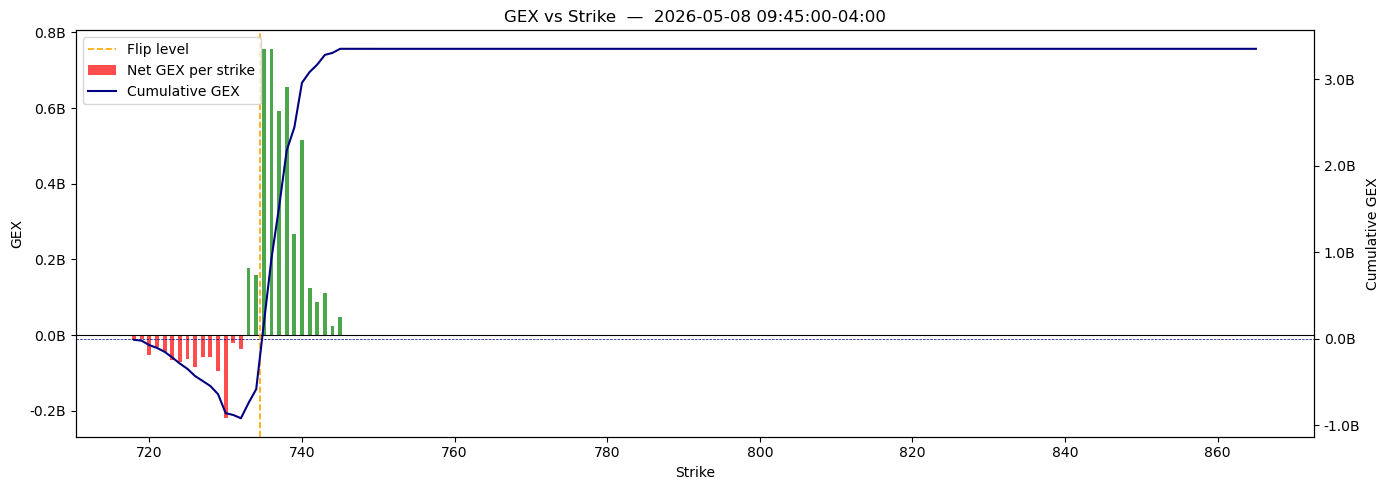

Flip levels at this timestamp: 1


In [6]:
ts = df["timestamp"].sort_values().unique()[50]  # change index to explore different timestamps

snap = (
    df[df["timestamp"] == ts]
    .groupby("strike")["gex"]
    .sum()
    .reset_index()
    .sort_values("strike")
)
snap["cum_gex"] = snap["gex"].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 5))
colors = ["green" if g >= 0 else "red" for g in snap["gex"]]
ax1.bar(snap["strike"], snap["gex"], color=colors, width=0.5, alpha=0.7, label="Net GEX per strike")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xlabel("Strike")
ax1.set_ylabel("GEX")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B"))

ax2 = ax1.twinx()
ax2.plot(snap["strike"], snap["cum_gex"], color="navy", linewidth=1.5, label="Cumulative GEX")
ax2.axhline(0, color="navy", linewidth=0.5, linestyle="--")
ax2.set_ylabel("Cumulative GEX")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B"))

signs = np.sign(snap["cum_gex"].values)
flip_idx = np.where(np.diff(signs) != 0)[0]
for k, i in enumerate(flip_idx):
    flip_strike = (snap["strike"].iloc[i] + snap["strike"].iloc[i + 1]) / 2
    ax1.axvline(flip_strike, color="orange", linewidth=1.2, linestyle="--",
                label="Flip level" if k == 0 else "")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title(f"GEX vs Strike  —  {ts}")
plt.tight_layout()
plt.show()
print(f"Flip levels at this timestamp: {len(flip_idx)}")

# Flip Count per Timestamp

Count how many times cumulative GEX crosses zero as we sweep from low to high strike. Each crossing is one flip level.

In [7]:
def count_flips(group):
    cum = group.groupby("strike")["gex"].sum().sort_index().cumsum()
    signs = np.sign(cum.values)
    signs = signs[signs != 0]
    return int((np.diff(signs) != 0).sum()) if len(signs) > 1 else 0

flip_counts = (
    df.groupby("timestamp")
    .apply(count_flips)
    .rename("n_flip_levels")
    .reset_index()
)
print(flip_counts.to_string(index=False))

                timestamp  n_flip_levels
2026-05-06 09:45:00-04:00              1
2026-05-06 10:00:00-04:00              1
2026-05-06 10:15:00-04:00              1
2026-05-06 10:30:00-04:00              1
2026-05-06 10:45:00-04:00              1
2026-05-06 11:00:00-04:00              1
2026-05-06 11:15:00-04:00              1
2026-05-06 11:30:00-04:00              1
2026-05-06 11:45:00-04:00              2
2026-05-06 12:00:00-04:00              1
2026-05-06 12:15:00-04:00              1
2026-05-06 12:30:00-04:00              1
2026-05-06 12:45:00-04:00              1
2026-05-06 13:00:00-04:00              2
2026-05-06 13:15:00-04:00              1
2026-05-06 13:30:00-04:00              1
2026-05-06 13:45:00-04:00              1
2026-05-06 14:00:00-04:00              1
2026-05-06 14:15:00-04:00              1
2026-05-06 14:30:00-04:00              1
2026-05-06 14:45:00-04:00              1
2026-05-06 15:00:00-04:00              1
2026-05-06 15:15:00-04:00              1
2026-05-06 15:30

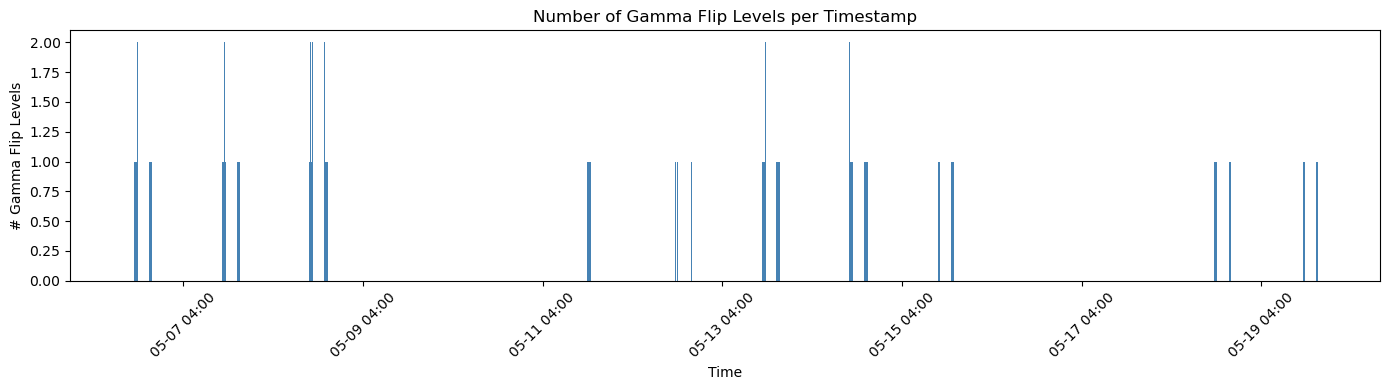

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(flip_counts["timestamp"], flip_counts["n_flip_levels"],
       width=pd.Timedelta(minutes=4), color="steelblue")
ax.set_xlabel("Time")
ax.set_ylabel("# Gamma Flip Levels")
ax.set_title("Number of Gamma Flip Levels per Timestamp")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%m-%d %H:%M"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()